# Notebook 09 - Late Fusion Multimodal Baseline

Notebook ini membuat baseline **late fusion** untuk MABSA hotel review.

Input utama:

1. Output Notebook 05: tokenized IndoBERT dataset.
2. Output Notebook 07: checkpoint text-only IndoBERT.
3. Output Notebook 08: CLIP image feature cache dan checkpoint image head.
4. Output Notebook 03: final review dataset dan relation taxonomy.

Target evaluasi utama tetap **`label_text_*`** sesuai keputusan Notebook 03. Label image digunakan sebagai **visual auxiliary evidence**, bukan untuk menimpa label teks.

Strategi:

- Ambil probabilitas text-only dari IndoBERT.
- Ambil probabilitas image-only dari CLIP head, lalu agregasi dari multi-image ke review-level.
- Cari bobot fusion di validation set.
- Evaluasi final di test set.
- Bandingkan `text_only`, `image_only_as_text_evidence`, `global_late_fusion`, `per_aspect_late_fusion`, dan `relation_aware_late_fusion`.

## Dasar Metodologis

Late fusion dipilih sebagai baseline multimodal pertama karena sederhana, transparan, dan mudah dibandingkan dengan unimodal baseline.

Dasar ilmiah:

1. **MABSA membutuhkan interaksi aspek-teks-gambar.** MIMN menunjukkan bahwa data multimodal pada aspect-level memiliki korelasi kompleks antara aspek, teks, dan gambar.

2. **Image bisa menjadi noise.** M2DF menekankan bahwa banyak gambar dalam MABSA tidak relevan dengan teks dan dapat menurunkan performa jika dipakai tanpa mekanisme denoising.

3. **Relevance-aware/gated fusion penting.** AMIFN membahas masalah aspect-image irrelevant dan memakai gate untuk menyaring noise visual. Notebook ini menerapkan versi baseline yang lebih sederhana: bobot fusion dipilih berdasarkan relation tag dan validation performance.

4. **Decision-level fusion dapat memakai validasi untuk mencari bobot.** Dalam multimodal sentiment analysis, decision fusion/weighted probability fusion sering dipakai sebagai baseline karena tidak mengubah encoder dasar dan memberi pembanding yang jelas sebelum model fusion yang lebih kompleks.

5. **Target utama tidak dicampur sembarangan.** Karena dataset ini memiliki `label_text_*` dan `label_image_*`, fusion dievaluasi terhadap `label_text_*` sebagai target ABSA utama, sementara image prediction hanya evidence tambahan.

Referensi:

- Xu, Mao, & Chen (2019), *Multi-Interactive Memory Network for Aspect Based Multimodal Sentiment Analysis*. https://ojs.aaai.org/index.php/AAAI/article/view/3807
- Zhao et al. (2023), *M2DF: Multi-grained Multi-curriculum Denoising Framework for Multimodal Aspect-based Sentiment Analysis*. https://arxiv.org/abs/2310.14605
- Yang et al. (2024), *AMIFN: Aspect-guided multi-view interactions and fusion network for multimodal aspect-based sentiment analysis*. https://doi.org/10.1016/j.neucom.2023.127222
- Chen et al. (2023), *Joint multimodal sentiment analysis based on information relevance*. https://doi.org/10.1016/j.ipm.2022.103193

### 1. Import Library dan Persiapan Lingkungan Eksekusi


In [1]:
from pathlib import Path
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

SEED = 42

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
LABEL_ORDER = ["None", "Negatif", "Netral", "Positif"]
LABEL_TO_ID = {"None": 0, "Negatif": 1, "Netral": 2, "Positif": 3}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
ASPECT_TO_ID = {aspect: idx for idx, aspect in enumerate(ASPECTS)}
SPLIT_TO_ID = {"train": 0, "val": 1, "test": 2}
ID_TO_SPLIT = {v: k for k, v in SPLIT_TO_ID.items()}

TEXT_BATCH_SIZE = int(os.environ.get("FUSION_TEXT_BATCH_SIZE", "32"))
IMAGE_HEAD_BATCH_SIZE = int(os.environ.get("FUSION_IMAGE_HEAD_BATCH_SIZE", "512"))
USE_AMP = os.environ.get("FUSION_USE_AMP", "1") == "1"

MIN_RELATION_GROUP_VAL_ROWS = int(os.environ.get("FUSION_MIN_RELATION_GROUP_VAL_ROWS", "40"))
FUSION_WEIGHT_GRID = [float(x) for x in os.environ.get(
    "FUSION_IMAGE_WEIGHT_GRID",
    "0,0.02,0.05,0.08,0.10,0.12,0.15,0.18,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.60"
).split(",")]
FUSION_WEIGHT_GRID = sorted(set([round(float(x), 4) for x in FUSION_WEIGHT_GRID if 0.0 <= float(x) <= 1.0]))

IMAGE_AGGREGATION_CANDIDATES = ["mean", "confidence_select", "max_pool"]

IS_KAGGLE = Path("/kaggle").exists()
OUTPUT_DIR = Path("/kaggle/working/mabsa_late_fusion_multimodal_baseline_outputs") if IS_KAGGLE else Path("mabsa_late_fusion_multimodal_baseline_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Kaggle environment:", IS_KAGGLE)
print("Text batch size:", TEXT_BATCH_SIZE)
print("Image head batch size:", IMAGE_HEAD_BATCH_SIZE)
print("Fusion weight grid:", FUSION_WEIGHT_GRID)

Output directory: /kaggle/working/mabsa_late_fusion_multimodal_baseline_outputs
Kaggle environment: True
Text batch size: 32
Image head batch size: 512
Fusion weight grid: [0.0, 0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.18, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6]


### 2. Pengaturan Seed untuk Reproduksibilitas (PyTorch, Numpy, Random)


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass


set_seed(SEED)

### 3. Validasi Lingkungan PyTorch GPU dan Framework Pendukung


In [3]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except ImportError as exc:
    raise ImportError("PyTorch tidak tersedia. Jalankan notebook ini di Kaggle GPU runtime.") from exc

try:
    from transformers import AutoModel
except ImportError:
    if IS_KAGGLE:
        print("transformers belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
        from transformers import AutoModel
    else:
        raise

try:
    from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
except ImportError:
    if IS_KAGGLE:
        print("scikit-learn belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
        from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
    else:
        raise

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 3))

Device: cuda
GPU: Tesla T4
Total VRAM GB: 14.563


## Resolve Input Files

Notebook ini bisa dijalankan di Kaggle dengan output Notebook 03, 05, 07, dan 08 sebagai input. Jika notebook sebelumnya dijalankan di sesi yang sama, file dari `/kaggle/working` juga akan terdeteksi.

### 4. Fungsi Pencarian Path Pre-trained Model dan Output Baseline (Teks/Gambar)


In [4]:
SEARCH_CACHE = {}


def all_search_roots():
    roots = []
    if IS_KAGGLE:
        roots.extend([
            Path("/kaggle/working"),
            Path("/kaggle/input"),
        ])
    roots.extend([
        Path(r"C:\Users\cencen04_\Documents\Codex\2026-05-23\files-mentioned-by-the-user-data"),
        Path(r"G:\Skripsi\Data Preprocessing"),
        Path(r"C:\Users\cencen04_\Downloads"),
    ])
    return [root for root in roots if root.exists()]


def path_score(path, preferred_substrings=None):
    text = str(path).replace("\\", "/").lower()
    score = 0
    preferred_substrings = preferred_substrings or []
    for idx, token in enumerate(preferred_substrings):
        if token.lower() in text:
            score += 100 - idx
    if "/kaggle/working/" in text:
        score += 20
    if "/kaggle/input/" in text:
        score += 10
    if "mabsa" in text:
        score += 5
    return score


def find_file(filename, preferred_substrings=None, required=True):
    cache_key = (filename, tuple(preferred_substrings or []))
    if cache_key in SEARCH_CACHE:
        return SEARCH_CACHE[cache_key]

    candidates = []
    for root in all_search_roots():
        direct = root / filename
        if direct.exists():
            candidates.append(direct)
        try:
            candidates.extend(root.rglob(filename))
        except Exception as exc:
            print(f"Skip search root {root}: {exc}")

    candidates = sorted(set(candidates), key=lambda p: path_score(p, preferred_substrings), reverse=True)
    if candidates:
        SEARCH_CACHE[cache_key] = candidates[0]
        return candidates[0]

    if required:
        raise FileNotFoundError(f"Tidak menemukan {filename}. Tambahkan output notebook sebelumnya sebagai Kaggle input.")
    return None


def find_glob(pattern, preferred_substrings=None, required=True):
    cache_key = ("glob", pattern, tuple(preferred_substrings or []))
    if cache_key in SEARCH_CACHE:
        return SEARCH_CACHE[cache_key]

    candidates = []
    for root in all_search_roots():
        try:
            candidates.extend(root.rglob(pattern))
        except Exception as exc:
            print(f"Skip glob root {root}: {exc}")

    candidates = sorted(set(candidates), key=lambda p: path_score(p, preferred_substrings), reverse=True)
    if candidates:
        SEARCH_CACHE[cache_key] = candidates[0]
        return candidates[0]

    if required:
        raise FileNotFoundError(f"Tidak menemukan pattern {pattern}.")
    return None


FINAL_REVIEW_PATH = find_file(
    "final_review_dataset_primary_training.csv",
    ["mabsa_final_dataset_outputs", "03"],
)
TEXT_NPZ_PATH = find_glob(
    "indobert_primary_training_maxlen*.npz",
    ["mabsa_text_indobert_preprocessing_outputs", "05"],
)
TEXT_METADATA_PATH = find_file(
    "text_preprocessed_primary_training.csv",
    ["mabsa_text_indobert_preprocessing_outputs", "05"],
)
TEXT_CHECKPOINT_PATH = find_file(
    "best_text_only_indobert.pt",
    ["mabsa_text_only_indobert_baseline_outputs", "07"],
)
IMAGE_FEATURE_CACHE_PATH = find_file(
    "clip_image_features_primary_training.npz",
    ["mabsa_image_only_clip_baseline_outputs", "08"],
)
IMAGE_HEAD_CHECKPOINT_PATH = find_file(
    "best_image_only_clip_head.pt",
    ["mabsa_image_only_clip_baseline_outputs", "08"],
)

TEXT_METRICS_PATH = find_file(
    "final_text_only_indobert_metrics.csv",
    ["mabsa_text_only_indobert_baseline_outputs", "07"],
    required=False,
)
IMAGE_METRICS_PATH = find_file(
    "final_image_only_clip_metrics.csv",
    ["mabsa_image_only_clip_baseline_outputs", "08"],
    required=False,
)

print("Final review:", FINAL_REVIEW_PATH)
print("Text NPZ:", TEXT_NPZ_PATH)
print("Text metadata:", TEXT_METADATA_PATH)
print("Text checkpoint:", TEXT_CHECKPOINT_PATH)
print("Image feature cache:", IMAGE_FEATURE_CACHE_PATH)
print("Image head checkpoint:", IMAGE_HEAD_CHECKPOINT_PATH)
print("Text metrics:", TEXT_METRICS_PATH)
print("Image metrics:", IMAGE_METRICS_PATH)

Final review: /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_primary_training.csv
Text NPZ: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/indobert_primary_training_maxlen256.npz
Text metadata: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/text_preprocessed_primary_training.csv
Text checkpoint: /kaggle/input/notebooks/vince0014/07-text-only-baseline-indobert/mabsa_text_only_indobert_baseline_outputs/best_text_only_indobert.pt
Image feature cache: /kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/clip_image_features_primary_training.npz
Image head checkpoint: /kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/best_image_only_clip_head.pt
Text metrics: /kaggle/input/not

### 5. Memuat Dataset Final Review, Label Teks, dan Metadata Multimodal


In [5]:
final_review = pd.read_csv(FINAL_REVIEW_PATH, keep_default_na=False)
text_metadata = pd.read_csv(TEXT_METADATA_PATH, keep_default_na=False)
text_npz = np.load(TEXT_NPZ_PATH, allow_pickle=True)

for df in [final_review, text_metadata]:
    df["ID_Review"] = df["ID_Review"].astype(str)

print("final_review shape:", final_review.shape)
print("text_metadata shape:", text_metadata.shape)
print("Text NPZ arrays:", {key: text_npz[key].shape for key in text_npz.files if hasattr(text_npz[key], "shape")})

review_meta_cols = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    "text_clean", "dataset_role", "split", "relation_category", "relation_strength",
    "policy_bucket", "recommended_fusion_strategy"
]
review_meta_cols = [col for col in review_meta_cols if col in final_review.columns]
review_meta = final_review[review_meta_cols].copy()

def normalize_label_value(value):
    if pd.isna(value):
        return "None"
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "null", "<na>"}:
        return "None"
    label_lookup = {
        "none": "None",
        "negatif": "Negatif",
        "netral": "Netral",
        "positif": "Positif",
    }
    return label_lookup.get(text.lower(), text)

invalid_target_rows = []
target_labels = np.zeros((len(review_meta), len(ASPECTS)), dtype=np.int64)

for aspect_idx, aspect in enumerate(ASPECTS):
    col = f"label_text_{aspect}"
    if col not in final_review.columns:
        raise ValueError(f"Kolom target hilang dari final_review: {col}")

    normalized = final_review[col].map(normalize_label_value)
    final_review[col] = normalized

    bad_mask = ~normalized.isin(LABEL_ORDER)
    if bad_mask.any():
        for row in final_review.loc[bad_mask, ["ID_Review", col]].head(20).itertuples(index=False):
            invalid_target_rows.append({"aspect": aspect, "ID_Review": row[0], "label": row[1]})

    target_labels[:, aspect_idx] = normalized.map(LABEL_TO_ID).astype(np.int64).to_numpy()

invalid_target_df = pd.DataFrame(invalid_target_rows)
if len(invalid_target_df):
    display(invalid_target_df)
    raise ValueError("Ada label_text invalid setelah normalisasi. Periksa final_review dataset.")

review_ids_final = final_review["ID_Review"].astype(str).to_numpy()
split_names = final_review["split"].astype(str).to_numpy()
split_ids = np.asarray([SPLIT_TO_ID[x] for x in split_names], dtype=np.int64)

display(review_meta["split"].value_counts().rename_axis("split").reset_index(name="count"))
display(review_meta["relation_category"].value_counts(dropna=False).rename_axis("relation_category").reset_index(name="count"))
display(final_review[["ID_Review", "split", "dataset_role", "relation_category"] + [f"label_text_{a}" for a in ASPECTS]].head(5))

final_review shape: (6854, 66)
text_metadata shape: (6854, 31)
Text NPZ arrays: {'input_ids': (6854, 256), 'attention_mask': (6854, 256), 'token_type_ids': (6854, 256), 'labels': (6854, 7), 'review_ids': (6854,), 'split_ids': (6854,), 'dataset_role_ids': (6854,)}


,split,count
0,train,4796
1,test,1029
2,val,1029


,relation_category,count
0,correlated_non_contradictive,4628
1,uncorrelated_different_aspects,1572
2,image_aspect_only,552
3,text_aspect_only,85
4,both_no_aspect,17


,ID_Review,split,dataset_role,relation_category,label_text_Kamar,label_text_Kebersihan,label_text_Pelayanan,label_text_Harga,label_text_Lokasi,label_text_Fasilitas,label_text_Makanan
0,10,test,relation_aware_training,uncorrelated_different_aspects,None,None,Positif,None,None,None,None
1,100,train,core_clean_training,correlated_non_contradictive,Netral,Positif,Positif,Positif,Positif,None,Netral
2,1001,train,core_clean_training,correlated_non_contradictive,None,None,Positif,None,Positif,None,Positif
3,1002,train,core_clean_training,correlated_non_contradictive,None,None,Positif,None,Positif,None,Positif
4,1003,train,core_clean_training,correlated_non_contradictive,None,None,None,None,Positif,None,Positif


## Text-Only Probability Inference

Model text-only dari Notebook 07 dimuat ulang untuk menghasilkan **soft probability**. Soft probability lebih cocok untuk late fusion dibanding hard label karena fusion membutuhkan derajat keyakinan tiap modality.

### 6. Definisi PyTorch Dataset untuk Memuat Output Teks (IndoBERT)


In [6]:
class IndoBertNpDataset(Dataset):
    def __init__(self, input_ids, attention_mask, token_type_ids, labels, review_ids):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.token_type_ids = torch.tensor(token_type_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.review_ids = np.asarray(review_ids).astype(str)

    def __len__(self):
        return len(self.review_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "token_type_ids": self.token_type_ids[idx],
            "labels": self.labels[idx],
            "review_id": self.review_ids[idx],
        }


class IndoBertMultiAspectClassifier(nn.Module):
    def __init__(self, model_name, num_aspects=7, num_labels=4, dropout=0.2):
        super().__init__()
        self.encoder_source = model_name
        try:
            self.encoder = AutoModel.from_pretrained(model_name)
        except Exception as first_error:
            print("Gagal load AutoModel dari model_name:", first_error)
            raise
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(hidden_size, num_labels) for _ in range(num_aspects)])

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        outputs = self.encoder(**kwargs)
        if getattr(outputs, "pooler_output", None) is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)
        logits = torch.stack([head(pooled) for head in self.heads], dim=1)
        return logits


def move_text_batch(batch):
    return {
        "input_ids": batch["input_ids"].to(device, non_blocking=True),
        "attention_mask": batch["attention_mask"].to(device, non_blocking=True),
        "token_type_ids": batch["token_type_ids"].to(device, non_blocking=True),
        "labels": batch["labels"].to(device, non_blocking=True),
        "review_id": batch["review_id"],
    }


try:
    text_checkpoint = torch.load(TEXT_CHECKPOINT_PATH, map_location=device, weights_only=False)
except TypeError:
    text_checkpoint = torch.load(TEXT_CHECKPOINT_PATH, map_location=device)
text_model_name = text_checkpoint.get("model_name", "indobenchmark/indobert-base-p1")
text_dropout = float(text_checkpoint.get("config", {}).get("dropout", 0.2))
text_model = IndoBertMultiAspectClassifier(
    model_name=text_model_name,
    num_aspects=len(ASPECTS),
    num_labels=len(LABEL_ORDER),
    dropout=text_dropout,
).to(device)
text_model.load_state_dict(text_checkpoint["model_state_dict"])
text_model.eval()

print("Loaded text checkpoint:", TEXT_CHECKPOINT_PATH)
print("Text model name:", text_model_name)
print("Text checkpoint best epoch:", text_checkpoint.get("best_epoch"))
print("Text checkpoint best val macro-F1:", text_checkpoint.get("best_val_macro_f1"))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loaded text checkpoint: /kaggle/input/notebooks/vince0014/07-text-only-baseline-indobert/mabsa_text_only_indobert_baseline_outputs/best_text_only_indobert.pt
Text model name: indobenchmark/indobert-base-p1
Text checkpoint best epoch: 5
Text checkpoint best val macro-F1: 0.598234


### 7. Pengambilan Tensor Logit/Probabilitas dari Model Baseline Teks


In [7]:
text_review_ids_npz = text_npz["review_ids"].astype(str)
text_dataset = IndoBertNpDataset(
    input_ids=text_npz["input_ids"],
    attention_mask=text_npz["attention_mask"],
    token_type_ids=text_npz["token_type_ids"],
    labels=text_npz["labels"],
    review_ids=text_review_ids_npz,
)
text_loader = DataLoader(
    text_dataset,
    batch_size=TEXT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

all_text_logits = []
all_text_labels = []
all_text_review_ids = []

iterator = tqdm(text_loader, desc="text inference") if tqdm is not None else text_loader
with torch.no_grad():
    for batch in iterator:
        batch = move_text_batch(batch)
        with torch.autocast(device_type="cuda", enabled=bool(USE_AMP and torch.cuda.is_available())):
            logits = text_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch["token_type_ids"],
            )
        all_text_logits.append(logits.detach().cpu().float())
        all_text_labels.append(batch["labels"].detach().cpu())
        all_text_review_ids.extend([str(x) for x in batch["review_id"]])

text_logits_npz_order = torch.cat(all_text_logits, dim=0).numpy().astype(np.float32)
text_probs_npz_order = torch.softmax(torch.tensor(text_logits_npz_order), dim=-1).numpy().astype(np.float32)
text_labels_npz_order = torch.cat(all_text_labels, dim=0).numpy().astype(np.int64)
text_review_ids_npz_order = np.asarray(all_text_review_ids).astype(str)

text_prob_by_review = {rid: text_probs_npz_order[idx] for idx, rid in enumerate(text_review_ids_npz_order)}
text_label_by_review = {rid: text_labels_npz_order[idx] for idx, rid in enumerate(text_review_ids_npz_order)}

missing_text_probs = [rid for rid in review_ids_final if rid not in text_prob_by_review]
if missing_text_probs:
    raise ValueError(f"Ada review di final_review yang tidak ada di text NPZ: contoh {missing_text_probs[:10]}")

text_probs = np.stack([text_prob_by_review[rid] for rid in review_ids_final], axis=0).astype(np.float32)
text_labels_from_npz = np.stack([text_label_by_review[rid] for rid in review_ids_final], axis=0).astype(np.int64)

if not np.array_equal(text_labels_from_npz, target_labels):
    mismatch_count = int((text_labels_from_npz != target_labels).sum())
    print("WARNING: target label dari NPZ berbeda dengan final_review cells:", mismatch_count)
else:
    print("Text labels aligned with final_review.")

print("text_probs:", text_probs.shape)

text inference:   0%|          | 0/215 [00:00<?, ?it/s]

Text labels aligned with final_review.
text_probs: (6854, 7, 4)


## Image-Only Probability Inference and Multi-Image Aggregation

Notebook 08 bekerja pada image-level. Untuk fusion dengan text review, probabilitas gambar perlu diagregasi ke **review-level**.

Tiga agregasi dicoba:

- `mean`: rata-rata semua gambar.
- `confidence_select`: pilih distribusi dari gambar paling yakin per aspek.
- `max_pool`: ambil probabilitas maksimum per label dari seluruh gambar, lalu normalisasi.

### 8. Definisi Arsitektur Model Classification Head Gambar (ViT/CLIP)


In [8]:
class MultiAspectImageHead(nn.Module):
    def __init__(self, input_dim, num_aspects=7, num_labels=4, dropout=0.25):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(input_dim, num_labels) for _ in range(num_aspects)])

    def forward(self, features):
        x = self.dropout(features)
        logits = torch.stack([head(x) for head in self.heads], dim=1)
        return logits


class ImageFeatureDataset(Dataset):
    def __init__(self, features, labels, review_ids, image_filenames):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.review_ids = np.asarray(review_ids).astype(str)
        self.image_filenames = np.asarray(image_filenames).astype(str)

    def __len__(self):
        return len(self.review_ids)

    def __getitem__(self, idx):
        return {
            "features": self.features[idx],
            "labels": self.labels[idx],
            "review_id": self.review_ids[idx],
            "image_filename": self.image_filenames[idx],
        }


image_cache = np.load(IMAGE_FEATURE_CACHE_PATH, allow_pickle=True)
image_features = image_cache["features"].astype(np.float32)
image_labels = image_cache["labels"].astype(np.int64)
image_review_ids = image_cache["review_ids"].astype(str)
image_filenames = image_cache["image_filenames"].astype(str)

try:
    image_checkpoint = torch.load(IMAGE_HEAD_CHECKPOINT_PATH, map_location=device, weights_only=False)
except TypeError:
    image_checkpoint = torch.load(IMAGE_HEAD_CHECKPOINT_PATH, map_location=device)
image_head_config = image_checkpoint.get("config", {})
image_head = MultiAspectImageHead(
    input_dim=int(image_checkpoint.get("input_dim", image_features.shape[1])),
    num_aspects=len(ASPECTS),
    num_labels=len(LABEL_ORDER),
    dropout=float(image_head_config.get("head_dropout", 0.25)),
).to(device)
image_head.load_state_dict(image_checkpoint["head_state_dict"])
image_head.eval()

print("Loaded image feature cache:", IMAGE_FEATURE_CACHE_PATH)
print("image_features:", image_features.shape)
print("image_labels:", image_labels.shape)
print("Loaded image head:", IMAGE_HEAD_CHECKPOINT_PATH)
print("Image checkpoint best epoch:", image_checkpoint.get("best_epoch"))
print("Image checkpoint best val macro-F1:", image_checkpoint.get("best_val_macro_f1"))

Loaded image feature cache: /kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/clip_image_features_primary_training.npz
image_features: (13976, 768)
image_labels: (13976, 7)
Loaded image head: /kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/best_image_only_clip_head.pt
Image checkpoint best epoch: 30
Image checkpoint best val macro-F1: 0.49939


### 9. Memuat Fitur dan Ekstraksi Logit dari Model Baseline Gambar


In [9]:
image_feature_dataset = ImageFeatureDataset(image_features, image_labels, image_review_ids, image_filenames)
image_feature_loader = DataLoader(
    image_feature_dataset,
    batch_size=IMAGE_HEAD_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

all_image_logits = []
all_image_review_ids = []
all_image_filenames = []

iterator = tqdm(image_feature_loader, desc="image head inference") if tqdm is not None else image_feature_loader
with torch.no_grad():
    for batch in iterator:
        features_batch = batch["features"].to(device, non_blocking=True)
        logits = image_head(features_batch)
        all_image_logits.append(logits.detach().cpu().float())
        all_image_review_ids.extend([str(x) for x in batch["review_id"]])
        all_image_filenames.extend([str(x) for x in batch["image_filename"]])

image_logits = torch.cat(all_image_logits, dim=0).numpy().astype(np.float32)
image_probs_image_level = torch.softmax(torch.tensor(image_logits), dim=-1).numpy().astype(np.float32)
image_review_ids = np.asarray(all_image_review_ids).astype(str)
image_filenames = np.asarray(all_image_filenames).astype(str)

print("image_probs_image_level:", image_probs_image_level.shape)
print("unique image review ids:", len(set(image_review_ids)))

image head inference:   0%|          | 0/28 [00:00<?, ?it/s]

image_probs_image_level: (13976, 7, 4)
unique image review ids: 6854


### 10. Agregasi Probabilitas Gambar per Review (Mean/Max/Confidence Pooling)


In [10]:
def entropy_from_probs(probs, eps=1e-12):
    return -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=-1)


def aggregate_image_probs_for_review(review_probs):
    # review_probs: [num_images, num_aspects, num_labels]
    mean_probs = review_probs.mean(axis=0)

    max_probs = review_probs.max(axis=0)
    max_probs = max_probs / np.clip(max_probs.sum(axis=-1, keepdims=True), 1e-12, None)

    ent = entropy_from_probs(review_probs)  # [num_images, num_aspects]
    best_idx = np.argmin(ent, axis=0)       # [num_aspects]
    confident = np.stack([review_probs[best_idx[aspect_idx], aspect_idx, :] for aspect_idx in range(len(ASPECTS))], axis=0)

    return {
        "mean": mean_probs.astype(np.float32),
        "max_pool": max_probs.astype(np.float32),
        "confidence_select": confident.astype(np.float32),
    }


review_to_image_indices = defaultdict(list)
for idx, rid in enumerate(image_review_ids):
    review_to_image_indices[str(rid)].append(idx)

image_probs_by_source = {source: [] for source in IMAGE_AGGREGATION_CANDIDATES}
image_count_per_review = []
missing_image_review_ids = []

for rid in review_ids_final:
    indices = review_to_image_indices.get(str(rid), [])
    image_count_per_review.append(len(indices))
    if not indices:
        missing_image_review_ids.append(str(rid))
        fallback = np.zeros((len(ASPECTS), len(LABEL_ORDER)), dtype=np.float32)
        fallback[:, 0] = 1.0
        for source in IMAGE_AGGREGATION_CANDIDATES:
            image_probs_by_source[source].append(fallback)
        continue

    review_probs = image_probs_image_level[indices]
    agg = aggregate_image_probs_for_review(review_probs)
    for source in IMAGE_AGGREGATION_CANDIDATES:
        image_probs_by_source[source].append(agg[source])

for source in IMAGE_AGGREGATION_CANDIDATES:
    image_probs_by_source[source] = np.stack(image_probs_by_source[source], axis=0).astype(np.float32)

image_count_per_review = np.asarray(image_count_per_review, dtype=np.int64)

print("Missing reviews without image features:", len(missing_image_review_ids))
print("Image count per review min/mean/max:", int(image_count_per_review.min()), round(float(image_count_per_review.mean()), 3), int(image_count_per_review.max()))
for source in IMAGE_AGGREGATION_CANDIDATES:
    print(source, image_probs_by_source[source].shape)

Missing reviews without image features: 0
Image count per review min/mean/max: 1 2.039 10
mean (6854, 7, 4)
confidence_select (6854, 7, 4)
max_pool (6854, 7, 4)


## Metrics Utilities

Metric utama adalah **macro-F1 rata-rata 7 aspek**. Weighted-F1 tetap disimpan, tetapi tidak menjadi dasar pemilihan model karena label `None` dominan.

### 11. Fungsi Evaluasi Metrik dan Konversi Probabilitas ke Prediksi Akhir


In [11]:
def probs_to_preds(probs):
    return probs.argmax(axis=-1).astype(np.int64)


def compute_metrics(labels_np, preds_np, split_name, strategy_name):
    rows = []
    macro_values = []
    weighted_values = []
    accuracy_values = []
    non_none_macro_values = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = labels_np[:, aspect_idx]
        y_pred = preds_np[:, aspect_idx]

        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="weighted", zero_division=0)
        non_none_macro_f1 = f1_score(y_true, y_pred, labels=[1, 2, 3], average="macro", zero_division=0)

        macro_values.append(macro_f1)
        weighted_values.append(weighted_f1)
        accuracy_values.append(accuracy)
        non_none_macro_values.append(non_none_macro_f1)

        rows.append({
            "strategy": strategy_name,
            "split": split_name,
            "aspect": aspect,
            "accuracy": round(float(accuracy), 6),
            "macro_f1": round(float(macro_f1), 6),
            "weighted_f1": round(float(weighted_f1), 6),
            "non_none_macro_f1": round(float(non_none_macro_f1), 6),
            "support": int(len(y_true)),
        })

    overall = {
        "strategy": strategy_name,
        "split": split_name,
        "aspect": "__overall_mean__",
        "accuracy": round(float(np.mean(accuracy_values)), 6),
        "macro_f1": round(float(np.mean(macro_values)), 6),
        "weighted_f1": round(float(np.mean(weighted_values)), 6),
        "non_none_macro_f1": round(float(np.mean(non_none_macro_values)), 6),
        "support": int(len(labels_np)),
    }
    rows.append(overall)
    return pd.DataFrame(rows), overall


def split_mask(split_name):
    return split_ids == SPLIT_TO_ID[split_name]


val_mask = split_mask("val")
test_mask = split_mask("test")
train_mask = split_mask("train")

print("train/val/test rows:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

train/val/test rows: 4796 1029 1029


### 12. Evaluasi dan Komparasi Kinerja Model Unimodal Baseline


In [12]:
baseline_metric_rows = []

text_preds = probs_to_preds(text_probs)
for split_name, mask in [("val", val_mask), ("test", test_mask)]:
    df, _ = compute_metrics(target_labels[mask], text_preds[mask], split_name, "text_only_recomputed")
    baseline_metric_rows.append(df)

for source in IMAGE_AGGREGATION_CANDIDATES:
    image_preds_as_text = probs_to_preds(image_probs_by_source[source])
    for split_name, mask in [("val", val_mask), ("test", test_mask)]:
        df, _ = compute_metrics(target_labels[mask], image_preds_as_text[mask], split_name, f"image_only_{source}_against_text_target")
        baseline_metric_rows.append(df)

baseline_metrics_df = pd.concat(baseline_metric_rows, ignore_index=True)
display(baseline_metrics_df.loc[baseline_metrics_df["aspect"].eq("__overall_mean__")])
baseline_metrics_df.to_csv(OUTPUT_DIR / "baseline_unimodal_recomputed_metrics.csv", index=False, encoding="utf-8-sig")

,strategy,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1,support
7,text_only_recomputed,val,__overall_mean__,0.853256,0.598234,0.850851,0.492638,1029
15,text_only_recomputed,test,__overall_mean__,0.851867,0.602641,0.850543,0.499142,1029
23,image_only_mean_against_text_target,val,__overall_mean__,0.562266,0.268739,0.512836,0.140831,1029
31,image_only_mean_against_text_target,test,__overall_mean__,0.558656,0.259721,0.511160,0.128349,1029
39,image_only_confidence_select_against_text_target,val,__overall_mean__,0.562543,0.269939,0.514659,0.141708,1029
47,image_only_confidence_select_against_text_target,test,__overall_mean__,0.560044,0.261708,0.513965,0.130221,1029
55,image_only_max_pool_against_text_target,val,__overall_mean__,0.562960,0.269536,0.514905,0.140693,1029
63,image_only_max_pool_against_text_target,test,__overall_mean__,0.559906,0.260488,0.513757,0.128393,1029


## Fusion Search on Validation Set

Bobot fusion dicari hanya di validation set, lalu dikunci untuk test set.

Formula:

`fused_prob = (1 - image_weight) * text_prob + image_weight * image_prob`

`image_weight = 0` berarti model kembali menjadi text-only. Ini sengaja disertakan agar fusion tidak dipaksa memakai gambar ketika gambar menjadi noise.

### 13. Pemetaan dan Validasi Grup Taksonomi Relasi Multimodal


In [13]:
def relation_group(value):
    text = str(value)
    if text == "correlated_non_contradictive":
        return "correlated"
    if text == "uncorrelated_different_aspects":
        return "uncorrelated"
    if text == "text_aspect_only":
        return "text_aspect_only"
    if text == "image_aspect_only":
        return "image_aspect_only"
    if text == "both_no_aspect":
        return "both_no_aspect"
    if text == "correlated_but_contradictive":
        return "contradiction"
    return "other"


review_relation_group = review_meta["relation_category"].map(relation_group).to_numpy()
relation_group_table = pd.Series(review_relation_group).value_counts().rename_axis("relation_group").reset_index(name="count")
display(relation_group_table)


def allowed_weights_for_group(group_name):
    if group_name == "correlated":
        max_weight = 0.60
    elif group_name in {"uncorrelated", "image_aspect_only"}:
        max_weight = 0.20
    elif group_name in {"text_aspect_only", "both_no_aspect"}:
        max_weight = 0.10
    elif group_name == "contradiction":
        max_weight = 0.08
    else:
        max_weight = 0.20
    return [w for w in FUSION_WEIGHT_GRID if w <= max_weight]


def fuse_probs(text_probs_input, image_probs_input, weight):
    return ((1.0 - weight) * text_probs_input + weight * image_probs_input).astype(np.float32)


def aspect_f1_for_probs(labels_np, probs_np, aspect_idx):
    preds = probs_np[:, aspect_idx, :].argmax(axis=-1)
    return f1_score(labels_np[:, aspect_idx], preds, labels=[0, 1, 2, 3], average="macro", zero_division=0)

,relation_group,count
0,correlated,4628
1,uncorrelated,1572
2,image_aspect_only,552
3,text_aspect_only,85
4,both_no_aspect,17


### 14. Pencarian Bobot Global Optimal untuk Late Fusion (Grid Search)


In [14]:
def search_global_fusion():
    rows = []
    best = None
    best_score = -1.0

    for source in IMAGE_AGGREGATION_CANDIDATES:
        image_probs_source = image_probs_by_source[source]
        for weight in allowed_weights_for_group("correlated"):
            fused_val = fuse_probs(text_probs[val_mask], image_probs_source[val_mask], weight)
            preds_val = probs_to_preds(fused_val)
            _, overall = compute_metrics(target_labels[val_mask], preds_val, "val", "tmp")
            row = {
                "strategy": "global_late_fusion",
                "source": source,
                "image_weight": weight,
                "val_macro_f1": overall["macro_f1"],
                "val_weighted_f1": overall["weighted_f1"],
                "val_non_none_macro_f1": overall["non_none_macro_f1"],
            }
            rows.append(row)
            if overall["macro_f1"] > best_score:
                best_score = float(overall["macro_f1"])
                best = row

    return best, pd.DataFrame(rows)


global_best, global_search_df = search_global_fusion()
display(pd.DataFrame([global_best]))
global_search_df.to_csv(OUTPUT_DIR / "fusion_search_global.csv", index=False, encoding="utf-8-sig")

,strategy,source,image_weight,val_macro_f1,val_weighted_f1,val_non_none_macro_f1
0,global_late_fusion,confidence_select,0.05,0.599562,0.852262,0.493925


### 15. Pencarian Bobot Late Fusion Spesifik per Aspek


In [15]:
def search_per_aspect_fusion():
    config_rows = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        best = None
        best_score = -1.0
        for source in IMAGE_AGGREGATION_CANDIDATES:
            image_probs_source = image_probs_by_source[source]
            for weight in allowed_weights_for_group("correlated"):
                fused_val = fuse_probs(text_probs[val_mask], image_probs_source[val_mask], weight)
                score = aspect_f1_for_probs(target_labels[val_mask], fused_val, aspect_idx)
                if score > best_score:
                    best_score = float(score)
                    best = {
                        "strategy": "per_aspect_late_fusion",
                        "aspect": aspect,
                        "relation_group": "__all__",
                        "source": source,
                        "image_weight": weight,
                        "val_aspect_macro_f1": round(best_score, 6),
                        "val_rows": int(val_mask.sum()),
                    }
        config_rows.append(best)

    return pd.DataFrame(config_rows)


per_aspect_config = search_per_aspect_fusion()
display(per_aspect_config)
per_aspect_config.to_csv(OUTPUT_DIR / "fusion_config_per_aspect.csv", index=False, encoding="utf-8-sig")

,strategy,aspect,relation_group,source,image_weight,val_aspect_macro_f1,val_rows
0,per_aspect_late_fusion,Kamar,__all__,max_pool,0.25,0.597315,1029
1,per_aspect_late_fusion,Kebersihan,__all__,confidence_select,0.20,0.619545,1029
2,per_aspect_late_fusion,Pelayanan,__all__,mean,0.05,0.688606,1029
3,per_aspect_late_fusion,Harga,__all__,confidence_select,0.30,0.594896,1029
4,per_aspect_late_fusion,Lokasi,__all__,confidence_select,0.08,0.502173,1029
5,per_aspect_late_fusion,Fasilitas,__all__,confidence_select,0.15,0.575030,1029
6,per_aspect_late_fusion,Makanan,__all__,mean,0.08,0.674447,1029


### 16. Pencarian Bobot Late Fusion Berbasis Taksonomi Relasi (Relation-Aware)


In [16]:
def search_relation_aware_fusion(per_aspect_default):
    config_rows = []
    relation_groups = sorted(set(review_relation_group))

    for aspect_idx, aspect in enumerate(ASPECTS):
        default_row = per_aspect_default.loc[per_aspect_default["aspect"].eq(aspect)].iloc[0].to_dict()

        for group in relation_groups:
            group_mask_val = val_mask & (review_relation_group == group)
            group_val_rows = int(group_mask_val.sum())

            if group_val_rows < MIN_RELATION_GROUP_VAL_ROWS:
                row = {
                    "strategy": "relation_aware_late_fusion",
                    "aspect": aspect,
                    "relation_group": group,
                    "source": default_row["source"],
                    "image_weight": float(default_row["image_weight"]),
                    "val_aspect_macro_f1": np.nan,
                    "val_rows": group_val_rows,
                    "fallback_used": True,
                    "fallback_reason": f"val rows < {MIN_RELATION_GROUP_VAL_ROWS}",
                }
                config_rows.append(row)
                continue

            best = None
            best_score = -1.0
            for source in IMAGE_AGGREGATION_CANDIDATES:
                image_probs_source = image_probs_by_source[source]
                for weight in allowed_weights_for_group(group):
                    fused_val = fuse_probs(text_probs[group_mask_val], image_probs_source[group_mask_val], weight)
                    score = aspect_f1_for_probs(target_labels[group_mask_val], fused_val, aspect_idx)
                    if score > best_score:
                        best_score = float(score)
                        best = {
                            "strategy": "relation_aware_late_fusion",
                            "aspect": aspect,
                            "relation_group": group,
                            "source": source,
                            "image_weight": weight,
                            "val_aspect_macro_f1": round(best_score, 6),
                            "val_rows": group_val_rows,
                            "fallback_used": False,
                            "fallback_reason": "",
                        }
            config_rows.append(best)

    return pd.DataFrame(config_rows)


relation_aware_config = search_relation_aware_fusion(per_aspect_config)
display(relation_aware_config)
relation_aware_config.to_csv(OUTPUT_DIR / "fusion_config_relation_aware.csv", index=False, encoding="utf-8-sig")

,strategy,aspect,relation_group,source,image_weight,val_aspect_macro_f1,val_rows,fallback_used,fallback_reason
0,relation_aware_late_fusion,Kamar,both_no_aspect,max_pool,0.25,NaN,3,True,val rows < 40
1,relation_aware_late_fusion,Kamar,correlated,max_pool,0.40,0.584176,694,False,
2,relation_aware_late_fusion,Kamar,image_aspect_only,mean,0.18,0.242236,83,False,
3,relation_aware_late_fusion,Kamar,text_aspect_only,max_pool,0.25,NaN,13,True,val rows < 40
4,relation_aware_late_fusion,Kamar,uncorrelated,confidence_select,0.20,0.643642,236,False,
5,relation_aware_late_fusion,Kebersihan,both_no_aspect,confidence_select,0.20,NaN,3,True,val rows < 40
6,relation_aware_late_fusion,Kebersihan,correlated,max_pool,0.40,0.622333,694,False,
7,relation_aware_late_fusion,Kebersihan,image_aspect_only,mean,0.00,0.245399,83,False,
8,relation_aware_late_fusion,Kebersihan,text_aspect_only,confidence_select,0.20,NaN,13,True,val rows < 40
9,relation_aware_late_fusion,Kebersihan,uncorrelated,mean,0.00,0.466997,236,False,


### 17. Kalkulasi Probabilitas Fusi Berdasarkan Konfigurasi Strategi Terbaik


In [17]:
def build_global_fused_probs(config_row):
    source = config_row["source"]
    weight = float(config_row["image_weight"])
    return fuse_probs(text_probs, image_probs_by_source[source], weight)


def build_per_aspect_fused_probs(config_df):
    fused = text_probs.copy()
    for _, row in config_df.iterrows():
        aspect_idx = ASPECT_TO_ID[row["aspect"]]
        source = row["source"]
        weight = float(row["image_weight"])
        fused[:, aspect_idx, :] = fuse_probs(
            text_probs[:, aspect_idx:aspect_idx + 1, :],
            image_probs_by_source[source][:, aspect_idx:aspect_idx + 1, :],
            weight,
        )[:, 0, :]
    return fused.astype(np.float32)


def build_relation_aware_fused_probs(config_df):
    fused = text_probs.copy()
    config_lookup = {}
    for _, row in config_df.iterrows():
        config_lookup[(row["aspect"], row["relation_group"])] = row

    for aspect in ASPECTS:
        aspect_idx = ASPECT_TO_ID[aspect]
        for group in sorted(set(review_relation_group)):
            mask = review_relation_group == group
            row = config_lookup[(aspect, group)]
            source = row["source"]
            weight = float(row["image_weight"])
            fused[mask, aspect_idx, :] = fuse_probs(
                text_probs[mask, aspect_idx:aspect_idx + 1, :],
                image_probs_by_source[source][mask, aspect_idx:aspect_idx + 1, :],
                weight,
            )[:, 0, :]
    return fused.astype(np.float32)


fusion_probabilities = {
    "text_only": text_probs,
    "global_late_fusion": build_global_fused_probs(global_best),
    "per_aspect_late_fusion": build_per_aspect_fused_probs(per_aspect_config),
    "relation_aware_late_fusion": build_relation_aware_fused_probs(relation_aware_config),
}

strategy_metric_rows = []
for strategy_name, probs in fusion_probabilities.items():
    preds = probs_to_preds(probs)
    for split_name, mask in [("val", val_mask), ("test", test_mask)]:
        df, _ = compute_metrics(target_labels[mask], preds[mask], split_name, strategy_name)
        strategy_metric_rows.append(df)

strategy_metrics_df = pd.concat(strategy_metric_rows, ignore_index=True)
strategy_summary_df = strategy_metrics_df.loc[strategy_metrics_df["aspect"].eq("__overall_mean__")].copy()

display(strategy_summary_df.sort_values(["split", "macro_f1"], ascending=[True, False]))
strategy_metrics_df.to_csv(OUTPUT_DIR / "late_fusion_strategy_metrics.csv", index=False, encoding="utf-8-sig")
strategy_summary_df.to_csv(OUTPUT_DIR / "late_fusion_strategy_summary.csv", index=False, encoding="utf-8-sig")

,strategy,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1,support
15,text_only,test,__overall_mean__,0.851867,0.602641,0.850543,0.499142,1029
31,global_late_fusion,test,__overall_mean__,0.852839,0.600588,0.850996,0.496180,1029
47,per_aspect_late_fusion,test,__overall_mean__,0.854089,0.598286,0.850737,0.493067,1029
63,relation_aware_late_fusion,test,__overall_mean__,0.848952,0.591520,0.845046,0.485691,1029
55,relation_aware_late_fusion,val,__overall_mean__,0.859503,0.611599,0.855295,0.509425,1029
39,per_aspect_late_fusion,val,__overall_mean__,0.859503,0.607430,0.854967,0.503730,1029
23,global_late_fusion,val,__overall_mean__,0.855060,0.599562,0.852262,0.493925,1029
7,text_only,val,__overall_mean__,0.853256,0.598234,0.850851,0.492638,1029


## Select Final Fusion Strategy

Strategi final dipilih berdasarkan validation macro-F1. Karena `text_only` ikut sebagai kandidat, pemilihan ini aman: kalau visual modality tidak membantu pada validasi, sistem akan memilih text-only sebagai baseline terbaik.

### 18. Seleksi Strategi Late Fusion Optimal Berdasarkan Metrik Validasi


In [18]:
val_summary = strategy_summary_df.loc[strategy_summary_df["split"].eq("val")].copy()
val_summary = val_summary.sort_values(["macro_f1", "non_none_macro_f1", "weighted_f1"], ascending=False)
selected_strategy = str(val_summary.iloc[0]["strategy"])

selected_probs = fusion_probabilities[selected_strategy]
selected_preds = probs_to_preds(selected_probs)

selected_metrics_rows = []
for split_name, mask in [("val", val_mask), ("test", test_mask)]:
    df, overall = compute_metrics(target_labels[mask], selected_preds[mask], split_name, selected_strategy)
    selected_metrics_rows.append(df)
    print(split_name, overall)

selected_metrics_df = pd.concat(selected_metrics_rows, ignore_index=True)
selected_metrics_df.to_csv(OUTPUT_DIR / "selected_late_fusion_metrics.csv", index=False, encoding="utf-8-sig")

display(pd.DataFrame([{
    "selected_strategy": selected_strategy,
    "selection_rule": "highest validation macro-F1 among text_only and late-fusion candidates",
    "val_macro_f1": float(val_summary.iloc[0]["macro_f1"]),
}]))
display(selected_metrics_df)

val {'strategy': 'relation_aware_late_fusion', 'split': 'val', 'aspect': '__overall_mean__', 'accuracy': 0.859503, 'macro_f1': 0.611599, 'weighted_f1': 0.855295, 'non_none_macro_f1': 0.509425, 'support': 1029}
test {'strategy': 'relation_aware_late_fusion', 'split': 'test', 'aspect': '__overall_mean__', 'accuracy': 0.848952, 'macro_f1': 0.59152, 'weighted_f1': 0.845046, 'non_none_macro_f1': 0.485691, 'support': 1029}


,selected_strategy,selection_rule,val_macro_f1
0,relation_aware_late_fusion,highest validation macro-F1 among text_only and late-fusion candidates,0.611599


,strategy,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1,support
0,relation_aware_late_fusion,val,Kamar,0.737609,0.602836,0.729647,0.531002,1029
1,relation_aware_late_fusion,val,Kebersihan,0.827988,0.624856,0.830274,0.536845,1029
2,relation_aware_late_fusion,val,Pelayanan,0.911565,0.697700,0.908635,0.617729,1029
3,relation_aware_late_fusion,val,Harga,0.933916,0.593899,0.928728,0.467490,1029
4,relation_aware_late_fusion,val,Lokasi,0.907677,0.502232,0.900514,0.357693,1029
5,relation_aware_late_fusion,val,Fasilitas,0.818270,0.579392,0.812584,0.465704,1029
6,relation_aware_late_fusion,val,Makanan,0.879495,0.680280,0.876685,0.589509,1029
7,relation_aware_late_fusion,val,__overall_mean__,0.859503,0.611599,0.855295,0.509425,1029
8,relation_aware_late_fusion,test,Kamar,0.703596,0.511767,0.687179,0.413966,1029
9,relation_aware_late_fusion,test,Kebersihan,0.803693,0.616131,0.808234,0.531050,1029


### 19. Penyusunan Dataframe Hasil Prediksi Kombinasi Late Fusion


In [19]:
def build_prediction_rows(probs, preds, strategy_name, split_name, mask):
    rows = []
    indices = np.where(mask)[0]
    for idx in indices:
        row = {
            "ID_Review": str(review_ids_final[idx]),
            "split": split_name,
            "strategy": strategy_name,
            "relation_category": review_meta.iloc[idx].get("relation_category", ""),
            "relation_group": review_relation_group[idx],
            "dataset_role": review_meta.iloc[idx].get("dataset_role", ""),
            "policy_bucket": review_meta.iloc[idx].get("policy_bucket", ""),
            "Text_Review": review_meta.iloc[idx].get("Text_Review", ""),
            "image_count": int(image_count_per_review[idx]),
        }
        for aspect_idx, aspect in enumerate(ASPECTS):
            true_id = int(target_labels[idx, aspect_idx])
            text_pred_id = int(text_preds[idx, aspect_idx])
            fused_pred_id = int(preds[idx, aspect_idx])
            row[f"true_{aspect}"] = ID_TO_LABEL[true_id]
            row[f"text_pred_{aspect}"] = ID_TO_LABEL[text_pred_id]
            row[f"fused_pred_{aspect}"] = ID_TO_LABEL[fused_pred_id]
            row[f"fused_correct_{aspect}"] = bool(true_id == fused_pred_id)
            row[f"text_conf_{aspect}"] = round(float(text_probs[idx, aspect_idx, text_pred_id]), 6)
            row[f"fused_conf_{aspect}"] = round(float(probs[idx, aspect_idx, fused_pred_id]), 6)
        rows.append(row)
    return pd.DataFrame(rows)


test_predictions = build_prediction_rows(selected_probs, selected_preds, selected_strategy, "test", test_mask)
val_predictions = build_prediction_rows(selected_probs, selected_preds, selected_strategy, "val", val_mask)

test_predictions.to_csv(OUTPUT_DIR / "test_predictions_selected_late_fusion.csv", index=False, encoding="utf-8-sig")
val_predictions.to_csv(OUTPUT_DIR / "val_predictions_selected_late_fusion.csv", index=False, encoding="utf-8-sig")

display(test_predictions.head(10))

,ID_Review,split,strategy,relation_category,relation_group,dataset_role,policy_bucket,Text_Review,image_count,true_Kamar,text_pred_Kamar,fused_pred_Kamar,fused_correct_Kamar,text_conf_Kamar,fused_conf_Kamar,true_Kebersihan,text_pred_Kebersihan,fused_pred_Kebersihan,fused_correct_Kebersihan,text_conf_Kebersihan,fused_conf_Kebersihan,true_Pelayanan,text_pred_Pelayanan,fused_pred_Pelayanan,fused_correct_Pelayanan,text_conf_Pelayanan,fused_conf_Pelayanan,true_Harga,text_pred_Harga,fused_pred_Harga,fused_correct_Harga,text_conf_Harga,fused_conf_Harga,true_Lokasi,text_pred_Lokasi,fused_pred_Lokasi,fused_correct_Lokasi,text_conf_Lokasi,fused_conf_Lokasi,true_Fasilitas,text_pred_Fasilitas,fused_pred_Fasilitas,fused_correct_Fasilitas,text_conf_Fasilitas,fused_conf_Fasilitas,true_Makanan,text_pred_Makanan,fused_pred_Makanan,fused_correct_Makanan,text_conf_Makanan,fused_conf_Makanan
0,10,test,relation_aware_late_fusion,uncorrelated_different_aspects,uncorrelated,relation_aware_training,relation_aware_training,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",2,None,None,None,True,0.966745,0.964745,None,None,None,True,0.984394,0.984394,Positif,Positif,Positif,True,0.945479,0.786162,None,None,None,True,0.974069,0.960971,None,None,None,True,0.719646,0.719646,None,None,None,True,0.957218,0.957218,None,None,None,True,0.810080,0.652669
1,1006,test,relation_aware_late_fusion,correlated_non_contradictive,correlated,core_clean_training,core_clean_training,"Buat yang mencari non stop hiburan YELLO Hotel ini sangat cocok. Setiap sudut begitu artsy dan instagramable. Fasilitas lengkap, ratenya terjangkau. Yang paling menyenangkan ad...",2,None,Positif,None,True,0.492592,0.473082,None,None,None,True,0.854099,0.554289,Positif,Positif,Positif,True,0.739032,0.739032,Positif,Positif,Positif,True,0.937399,0.799360,Positif,Positif,Positif,True,0.925970,0.928948,Positif,Positif,Positif,True,0.772227,0.663527,None,None,None,True,0.666962,0.690666
2,1008,test,relation_aware_late_fusion,correlated_non_contradictive,correlated,core_clean_training,core_clean_training,Hotel Yello Paskal ini sangat menyenangkan buat kami (pasangan) maupun keluarga yang ingin bersantai dan menikmati liburan di Bandung. Pelayanan juga cepat dan ramah dan sangat...,1,Positif,Positif,Positif,True,0.905985,0.590700,None,None,None,True,0.881639,0.536426,Positif,Positif,Positif,True,0.967270,0.967270,Positif,None,None,False,0.930733,0.939528,None,None,None,True,0.850438,0.784281,Positif,None,None,False,0.567404,0.515344,None,None,None,True,0.931688,0.929321
3,1018,test,relation_aware_late_fusion,correlated_non_contradictive,correlated,core_clean_training,core_clean_training,"Lokasi bagus, kamar cantik dan saya mendapat harga terbaik dari aplikasi, pasti akan segera kembali ke sini 😎",4,Positif,Positif,Positif,True,0.801377,0.659329,None,None,None,True,0.952113,0.587860,None,None,None,True,0.785377,0.785377,Positif,Positif,Positif,True,0.857574,0.730413,Positif,None,None,False,0.771757,0.712459,None,None,None,True,0.885397,0.894357,None,None,None,True,0.966542,0.963375
4,1020,test,relation_aware_late_fusion,correlated_non_contradictive,correlated,core_clean_training,core_clean_training,"Sempurna untuk anggaran hotel, sarapannya baik, kebersihan kamarnya bagus, pemandangan kamarnya sangat keren, Anda bisa melihat gunung bandung dari kamar Anda dan yang terpenti...",3,Positif,Positif,Positif,True,0.891467,0.721173,Positif,Positif,Positif,True,0.926711,0.863317,None,None,None,True,0.853973,0.853973,Positif,None,None,False,0.703104,0.746355,Positif,Positif,Positif,True,0.963221,0.963511,None,None,None,True,0.687819,0.727739,Positif,Positif,Positif,True,0.794080,0.732893
5,1036,test,relation_aware_late_fusion,correlated_non_contradictive,correlated,core_clean_training,core_clean_training,"hotel yang sangat menarik! sangat direkomendasikan! semua bersih, semua staf rendah hati, setiap tempa

### 20. Kalkulasi Laporan Metrik Kinerja Akhir (Classification Report)


In [20]:
report_rows = []
confusion_rows = []

for split_name, mask in [("val", val_mask), ("test", test_mask)]:
    y_true_all = target_labels[mask]
    y_pred_all = selected_preds[mask]
    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = y_true_all[:, aspect_idx]
        y_pred = y_pred_all[:, aspect_idx]

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3],
            target_names=LABEL_ORDER,
            zero_division=0,
            output_dict=True,
        )

        for label_name in LABEL_ORDER + ["macro avg", "weighted avg"]:
            values = report[label_name]
            report_rows.append({
                "strategy": selected_strategy,
                "split": split_name,
                "aspect": aspect,
                "label": label_name,
                "precision": round(float(values["precision"]), 6),
                "recall": round(float(values["recall"]), 6),
                "f1_score": round(float(values["f1-score"]), 6),
                "support": int(values["support"]),
            })

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
        for true_idx, true_label in enumerate(LABEL_ORDER):
            for pred_idx, pred_label in enumerate(LABEL_ORDER):
                confusion_rows.append({
                    "strategy": selected_strategy,
                    "split": split_name,
                    "aspect": aspect,
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "count": int(cm[true_idx, pred_idx]),
                })

classification_report_df = pd.DataFrame(report_rows)
confusion_matrix_df = pd.DataFrame(confusion_rows)

classification_report_df.to_csv(OUTPUT_DIR / "classification_report_selected_late_fusion.csv", index=False, encoding="utf-8-sig")
confusion_matrix_df.to_csv(OUTPUT_DIR / "confusion_matrix_selected_late_fusion_long.csv", index=False, encoding="utf-8-sig")

display(classification_report_df.head(50))
display(confusion_matrix_df.head(50))

,strategy,split,aspect,label,precision,recall,f1_score,support
0,relation_aware_late_fusion,val,Kamar,None,0.765079,0.879562,0.818336,548
1,relation_aware_late_fusion,val,Kamar,Negatif,0.654762,0.591398,0.621469,93
2,relation_aware_late_fusion,val,Kamar,Netral,0.342857,0.260870,0.296296,46
3,relation_aware_late_fusion,val,Kamar,Positif,0.750000,0.614035,0.675241,342
4,relation_aware_late_fusion,val,Kamar,macro avg,0.628175,0.586466,0.602836,1029
5,relation_aware_late_fusion,val,Kamar,weighted avg,0.731222,0.737609,0.729647,1029
6,relation_aware_late_fusion,val,Kebersihan,None,0.938843,0.843982,0.888889,673
7,relation_aware_late_fusion,val,Kebersihan,Negatif,0.661290,0.854167,0.745455,48
8,relation_aware_late_fusion,val,Kebersihan,Netral,0.117647,0.086957,0.100000,23
9,relation_aware_late_fusion,val,Kebersihan,Positif,0.698551,0.845614,0.765079,285


,strategy,split,aspect,true_label,pred_label,count
0,relation_aware_late_fusion,val,Kamar,None,None,482
1,relation_aware_late_fusion,val,Kamar,None,Negatif,15
2,relation_aware_late_fusion,val,Kamar,None,Netral,4
3,relation_aware_late_fusion,val,Kamar,None,Positif,47
4,relation_aware_late_fusion,val,Kamar,Negatif,None,20
5,relation_aware_late_fusion,val,Kamar,Negatif,Negatif,55
6,relation_aware_late_fusion,val,Kamar,Negatif,Netral,8
7,relation_aware_late_fusion,val,Kamar,Negatif,Positif,10
8,relation_aware_late_fusion,val,Kamar,Netral,None,13
9,relation_aware_late_fusion,val,Kamar,Netral,Negatif,8


### 21. Komparasi Lintas Metrik: Model Teks, Gambar, dan Late Fusion


In [21]:
comparison_rows = []
if TEXT_METRICS_PATH is not None:
    try:
        text_external = pd.read_csv(TEXT_METRICS_PATH)
        text_external_overall = text_external.loc[
            text_external["split"].eq("test") & text_external["aspect"].eq("__overall_mean__")
        ].iloc[0].to_dict()
        comparison_rows.append({
            "model": "Notebook07_text_only_reported",
            "target": "label_text_*",
            "test_accuracy": text_external_overall.get("accuracy"),
            "test_macro_f1": text_external_overall.get("macro_f1"),
            "test_weighted_f1": text_external_overall.get("weighted_f1"),
            "test_non_none_macro_f1": text_external_overall.get("non_none_macro_f1"),
            "note": "reported by Notebook 07",
        })
    except Exception as exc:
        print("Could not read text metrics:", exc)

if IMAGE_METRICS_PATH is not None:
    try:
        image_external = pd.read_csv(IMAGE_METRICS_PATH)
        image_external_overall = image_external.loc[
            image_external["split"].eq("test") & image_external["aspect"].eq("__overall_mean__")
        ].iloc[0].to_dict()
        comparison_rows.append({
            "model": "Notebook08_image_only_reported",
            "target": "label_image_*",
            "test_accuracy": image_external_overall.get("accuracy"),
            "test_macro_f1": image_external_overall.get("macro_f1"),
            "test_weighted_f1": image_external_overall.get("weighted_f1"),
            "test_non_none_macro_f1": image_external_overall.get("non_none_macro_f1"),
            "note": "not directly comparable because target is label_image_*",
        })
    except Exception as exc:
        print("Could not read image metrics:", exc)

for _, row in strategy_summary_df.loc[strategy_summary_df["split"].eq("test")].iterrows():
    comparison_rows.append({
        "model": row["strategy"],
        "target": "label_text_*",
        "test_accuracy": row["accuracy"],
        "test_macro_f1": row["macro_f1"],
        "test_weighted_f1": row["weighted_f1"],
        "test_non_none_macro_f1": row["non_none_macro_f1"],
        "note": "recomputed in Notebook 09",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUT_DIR / "notebook07_08_09_comparison.csv", index=False, encoding="utf-8-sig")
display(comparison_df)

,model,target,test_accuracy,test_macro_f1,test_weighted_f1,test_non_none_macro_f1,note
0,Notebook07_text_only_reported,label_text_*,0.851728,0.602567,0.850413,0.499095,reported by Notebook 07
1,Notebook08_image_only_reported,label_image_*,0.913801,0.522666,0.911843,0.384029,not directly comparable because target is label_image_*
2,text_only,label_text_*,0.851867,0.602641,0.850543,0.499142,recomputed in Notebook 09
3,global_late_fusion,label_text_*,0.852839,0.600588,0.850996,0.496180,recomputed in Notebook 09
4,per_aspect_late_fusion,label_text_*,0.854089,0.598286,0.850737,0.493067,recomputed in Notebook 09
5,relation_aware_late_fusion,label_text_*,0.848952,0.591520,0.845046,0.485691,recomputed in Notebook 09


### 22. Penyimpanan Tensor Cache Probabilitas Fusi ke Format NPZ


In [22]:
np.savez_compressed(
    OUTPUT_DIR / "late_fusion_probability_cache_review_level.npz",
    review_ids=review_ids_final.astype(str),
    split_ids=split_ids.astype(np.int64),
    target_labels=target_labels.astype(np.int64),
    text_probs=text_probs.astype(np.float32),
    image_probs_mean=image_probs_by_source["mean"].astype(np.float32),
    image_probs_confidence_select=image_probs_by_source["confidence_select"].astype(np.float32),
    image_probs_max_pool=image_probs_by_source["max_pool"].astype(np.float32),
    selected_probs=selected_probs.astype(np.float32),
    selected_preds=selected_preds.astype(np.int64),
    relation_group=np.asarray(review_relation_group).astype(str),
)

methodology_notes = f"""# Methodology Notes - Notebook 09 Late Fusion Multimodal Baseline

## Tujuan

Notebook 09 membangun baseline multimodal decision-level fusion dari text-only IndoBERT dan image-only CLIP head.

## Target

Target utama evaluasi adalah `label_text_*`, sesuai kebijakan Notebook 03. Image prediction diperlakukan sebagai visual auxiliary evidence, bukan pengganti label teks.

## Dasar Metodologi

1. MIMN menunjukkan bahwa MABSA memerlukan pemodelan hubungan aspek, teks, dan gambar.
2. M2DF menunjukkan bahwa gambar yang tidak relevan dapat menjadi noise dalam MABSA.
3. AMIFN menunjukkan pentingnya gating/relevance filtering pada visual modality.
4. Late fusion dipakai sebagai baseline transparan sebelum cross-modal/gated fusion Notebook 10.
5. Bobot fusion dicari pada validation set dan diuji sekali pada test set.

## Strategi Terpilih

- Selected strategy: {selected_strategy}
- Selection rule: highest validation macro-F1 among text_only and late-fusion candidates.

## Output Penting

- `late_fusion_strategy_summary.csv`
- `selected_late_fusion_metrics.csv`
- `fusion_config_per_aspect.csv`
- `fusion_config_relation_aware.csv`
- `test_predictions_selected_late_fusion.csv`
- `notebook07_08_09_comparison.csv`
"""

with open(OUTPUT_DIR / "methodology_notes_notebook_09.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

config = {
    "seed": SEED,
    "selected_strategy": selected_strategy,
    "fusion_weight_grid": FUSION_WEIGHT_GRID,
    "image_aggregation_candidates": IMAGE_AGGREGATION_CANDIDATES,
    "min_relation_group_val_rows": MIN_RELATION_GROUP_VAL_ROWS,
    "text_checkpoint_path": str(TEXT_CHECKPOINT_PATH),
    "image_head_checkpoint_path": str(IMAGE_HEAD_CHECKPOINT_PATH),
    "image_feature_cache_path": str(IMAGE_FEATURE_CACHE_PATH),
    "target": "label_text_*",
    "aspects": ASPECTS,
    "label_to_id": LABEL_TO_ID,
    "rows": {
        "train": int(train_mask.sum()),
        "val": int(val_mask.sum()),
        "test": int(test_mask.sum()),
    },
}
with open(OUTPUT_DIR / "late_fusion_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print(json.dumps(config, ensure_ascii=False, indent=2))

{
  "seed": 42,
  "selected_strategy": "relation_aware_late_fusion",
  "fusion_weight_grid": [
    0.0,
    0.02,
    0.05,
    0.08,
    0.1,
    0.12,
    0.15,
    0.18,
    0.2,
    0.25,
    0.3,
    0.35,
    0.4,
    0.45,
    0.5,
    0.6
  ],
  "image_aggregation_candidates": [
    "mean",
    "confidence_select",
    "max_pool"
  ],
  "min_relation_group_val_rows": 40,
  "text_checkpoint_path": "/kaggle/input/notebooks/vince0014/07-text-only-baseline-indobert/mabsa_text_only_indobert_baseline_outputs/best_text_only_indobert.pt",
  "image_head_checkpoint_path": "/kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/best_image_only_clip_head.pt",
  "image_feature_cache_path": "/kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/clip_image_features_primary_training.npz",
  "target": "label_text_*",
  "aspects": [
    "Kamar",
    "Kebersihan",
    "Pelayanan",
    "Harga

### 23. Verifikasi Akhir Integritas Output Eksperimen (Critical Checks)


In [23]:
checks = []
checks.append({"check": "final_review_has_rows", "value": int(len(final_review) > 0), "expected": 1})
checks.append({"check": "text_probs_shape", "value": list(text_probs.shape), "expected": [int(len(final_review)), len(ASPECTS), len(LABEL_ORDER)]})
checks.append({"check": "image_probs_mean_shape", "value": list(image_probs_by_source["mean"].shape), "expected": [int(len(final_review)), len(ASPECTS), len(LABEL_ORDER)]})
checks.append({"check": "missing_image_review_ids", "value": int(len(missing_image_review_ids)), "expected": 0})
checks.append({"check": "selected_strategy_exists", "value": int(selected_strategy in fusion_probabilities), "expected": 1})
checks.append({"check": "selected_metrics_exists", "value": int((OUTPUT_DIR / "selected_late_fusion_metrics.csv").exists()), "expected": 1})
checks.append({"check": "strategy_summary_exists", "value": int((OUTPUT_DIR / "late_fusion_strategy_summary.csv").exists()), "expected": 1})
checks.append({"check": "test_predictions_exists", "value": int((OUTPUT_DIR / "test_predictions_selected_late_fusion.csv").exists()), "expected": 1})
checks.append({"check": "comparison_exists", "value": int((OUTPUT_DIR / "notebook07_08_09_comparison.csv").exists()), "expected": 1})

selected_test_overall = selected_metrics_df.loc[
    selected_metrics_df["split"].eq("test") & selected_metrics_df["aspect"].eq("__overall_mean__")
].iloc[0]
checks.append({"check": "selected_test_macro_f1_valid_range", "value": int(0.0 <= float(selected_test_overall["macro_f1"]) <= 1.0), "expected": 1})

checks_df = pd.DataFrame(checks)
checks_df["status"] = checks_df.apply(lambda row: "OK" if row["value"] == row["expected"] else "NEEDS_REVIEW", axis=1)
checks_df.to_csv(OUTPUT_DIR / "notebook_09_checks.csv", index=False, encoding="utf-8-sig")
display(checks_df)

if (checks_df["status"] == "NEEDS_REVIEW").any():
    print("Notebook 09 selesai dengan catatan. Periksa NEEDS_REVIEW sebelum Notebook 10.")
else:
    print("Notebook 09 selesai. Late fusion baseline siap dianalisis dan dibandingkan dengan Notebook 10.")

,check,value,expected,status
0,final_review_has_rows,1,1,OK
1,text_probs_shape,"[6854, 7, 4]","[6854, 7, 4]",OK
2,image_probs_mean_shape,"[6854, 7, 4]","[6854, 7, 4]",OK
3,missing_image_review_ids,0,0,OK
4,selected_strategy_exists,1,1,OK
5,selected_metrics_exists,1,1,OK
6,strategy_summary_exists,1,1,OK
7,test_predictions_exists,1,1,OK
8,comparison_exists,1,1,OK
9,selected_test_macro_f1_valid_range,1,1,OK


Notebook 09 selesai. Late fusion baseline siap dianalisis dan dibandingkan dengan Notebook 10.


### 24. Visualisasi Komparasi Kinerja Antar Strategi Late Fusion


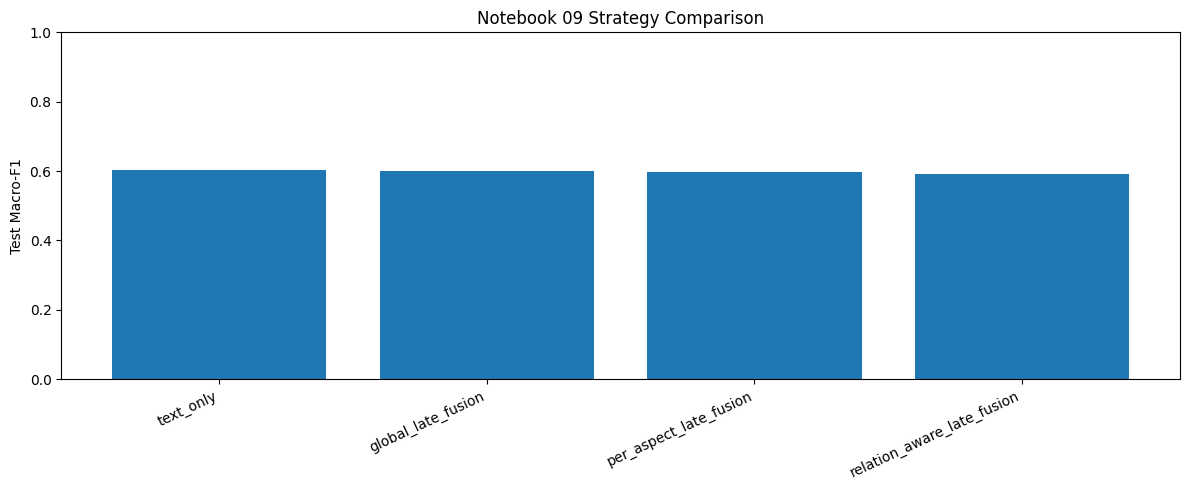

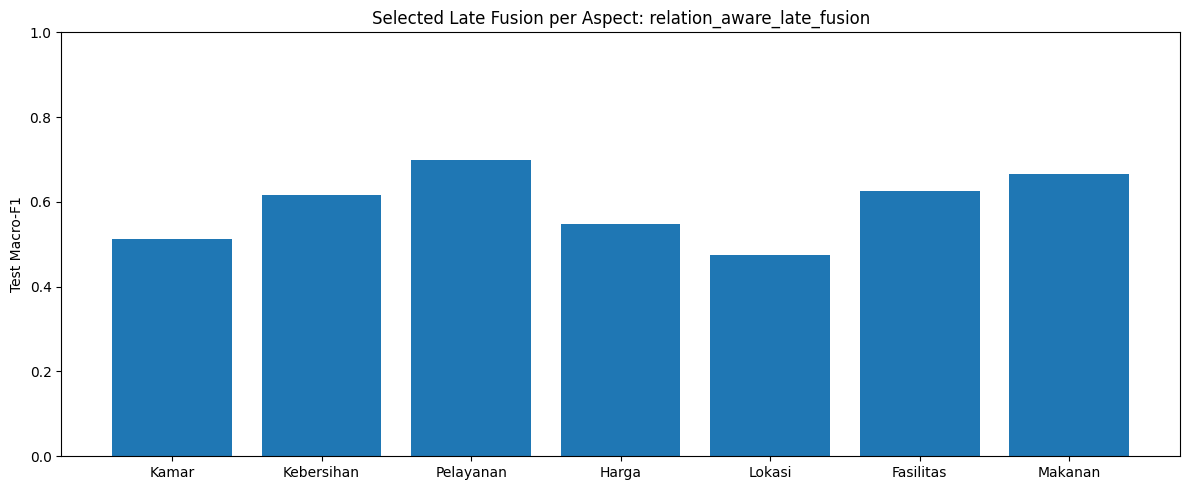

In [24]:
try:
    import matplotlib.pyplot as plt

    summary_plot = strategy_summary_df.loc[strategy_summary_df["split"].eq("test")].copy()
    summary_plot = summary_plot.sort_values("macro_f1", ascending=False)
    plt.figure(figsize=(12, 5))
    plt.bar(summary_plot["strategy"], summary_plot["macro_f1"])
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Test Macro-F1")
    plt.title("Notebook 09 Strategy Comparison")
    plt.tight_layout()
    plt.show()

    aspect_plot = selected_metrics_df.loc[
        selected_metrics_df["split"].eq("test") & selected_metrics_df["aspect"].ne("__overall_mean__")
    ].copy()
    plt.figure(figsize=(12, 5))
    plt.bar(aspect_plot["aspect"], aspect_plot["macro_f1"])
    plt.ylim(0, 1)
    plt.ylabel("Test Macro-F1")
    plt.title(f"Selected Late Fusion per Aspect: {selected_strategy}")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Visualization skipped:", exc)

### 25. Kompresi Seluruh Output Baseline Late Fusion ke Arsip ZIP


In [25]:
zip_base = OUTPUT_DIR.parent / "mabsa_late_fusion_multimodal_baseline_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print("ZIP output:", zip_path)
print("\nFiles in output directory:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

ZIP output: /kaggle/working/mabsa_late_fusion_multimodal_baseline_outputs.zip

Files in output directory:
- baseline_unimodal_recomputed_metrics.csv
- classification_report_selected_late_fusion.csv
- confusion_matrix_selected_late_fusion_long.csv
- fusion_config_per_aspect.csv
- fusion_config_relation_aware.csv
- fusion_search_global.csv
- late_fusion_config.json
- late_fusion_probability_cache_review_level.npz
- late_fusion_strategy_metrics.csv
- late_fusion_strategy_summary.csv
- methodology_notes_notebook_09.md
- notebook07_08_09_comparison.csv
- notebook_09_checks.csv
- selected_late_fusion_metrics.csv
- test_predictions_selected_late_fusion.csv
- val_predictions_selected_late_fusion.csv
